---

# `Instruções para o teste`

## ⚠️ Importante

Antes de iniciar, não esqueça de renomear esse documento substituindo o texto **SEU_NOME** no título com o nome de quem for resolver.

Deixe as respostas bem sinalizadas e comentadas e mencionando a qual questão se refere.

Fique à vontade para utilizar quantas células forem necessárias.

<br><br>

## 📖 Recursos Permitidos
✅ Documentação, sites, fóruns  
❌ Inteligências Artificiais (ChatGPT, Claude, etc.)

<br><br>

## 📤 Instruções para Entrega

**Ao finalizar o teste** volte a este passo e execute a célula abaixo.

**Envie o arquivo gerado e o arquivo do seu notebook para o e-mail:** `mateus.camacho@tdwbi.com.br`

- Arquivo gerado: `historico_exec.txt` <br>
- Seu notebook: `teste_spark_SEU_NOME.ipynb`


In [ ]:
with open('/content/historico_exec.txt', 'w') as f:
    for i, cmd in enumerate(In):
        if cmd.strip():
            f.write(f"\n\nIn[{i}]:\n{cmd}\n\n")

# Baixar arquivo
from google.colab import files
files.download('/content/historico_exec.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# `Questões e Contexto`

## 📁 Contexto

No diretório raiz desse documento, existem os três arquivos que serão necessários para a conclusão dessa atividade. Em caso de dúvidas, a pasta de se encontra no desktop dessa máquina na pasta 'pyspark_test'.

Os dados são fictícios e compreendem uma simulação de um cenário de uma loja de departamentos, para isso temos os arquivos com as seguintes informações:
- **users.csv** → Dados dos clientes/usuários da loja
- **sales.csv** → Dados das vendas
- **products.json** → Dados de cadastro dos produtos

<br><br>

## 📝 Questões

A atividade consiste nas questões a seguir:

**1.** Declare um novo dataframe que mostre o nome do produto e o valor final da compra.

**2.** Declare um novo dataframe com o valor total gasto por cliente.

**3.** Declare um novo dataframe com os cinco melhores clientes contendo o nome, e-mail e o valor gasto em todo o período.

**4.** Declare um novo dataframe com os cinco produtos mais vendidos nos últimos seis meses (considerando período de dados disponível nos arquivos) contendo o nome do produto e a quantidade de produtos vendidos nesse período.

**5.** Calcular a média de faturamento por cliente e o desvio padrão.

**6.** Classificar os clientes em três categorias: silver, gold, platinum
- **platinum:** clientes que gastaram mais que a média de faturamento por cliente;
- **gold:** clientes que gastaram do menor desvio padrão até a média de faturamento por cliente;
- **silver:** clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente;

**7.** Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente.

---

# `Configuração do ambiente`

**Execute as células abaixo antes de iniciar o teste.**

Os arquivos serão criados automaticamente e estarão disponíveis no ícone de pasta do menu lateral (conforme imagem abaixo) ou na pasta **content**.

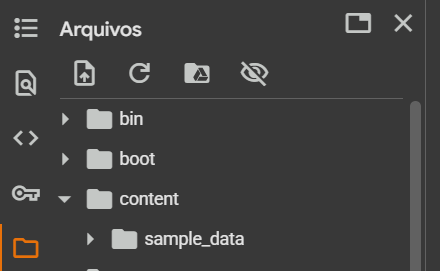


In [9]:
### IMPORTANDO ARQUIVOS QUE SERÃO USADOS NO TESTE ###

!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json -O products.json
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv -O sales.csv
!wget https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/users.csv -O users.csv

path_products = "/content/products.json"
path_sales = "/content/sales.csv"
path_users = "/content/users.csv"

--2026-07-09 13:17:24--  https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/products.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3186 (3.1K) [text/plain]
Saving to: ‘products.json’

products.json       100%[===================>]   3.11K  --.-KB/s    in 0s      

2026-07-09 13:17:24 (38.2 MB/s) - ‘products.json’ saved [3186/3186]

--2026-07-09 13:17:24--  https://raw.githubusercontent.com/KaelDucatti/pyspark_test_data/main/sales.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24411 (24K) [text/plain]


In [11]:
### IMPORTANDO BIBLIOTECAS NECESSÁRIAS ###

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [12]:
### INSTANCIANDO SPARK ###

spark = SparkSession.builder.appName('test-spark').getOrCreate()

## Carregando os Dados

In [13]:
# Carregando users.csv
users_df = spark.read.csv(path_users, header=True, inferSchema=True)
print("Schema do users_df:")
users_df.printSchema()
print("Primeiras 5 linhas do users_df:")
users_df.show(5)

Schema do users_df:
root
 |-- client_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- login: string (nullable = true)
 |-- password: string (nullable = true)

Primeiras 5 linhas do users_df:
+---------+-------------------+--------------------+------+--------------+----------------+
|client_id|               name|               email|gender|         login|        password|
+---------+-------------------+--------------------+------+--------------+----------------+
|        1|   Mitch Kilpatrick|mkilpatrick0@cdc.gov|     M|  mkilpatrick0|      uE9+F7h5*P|
|        2|          Kit Kyncl|kkyncl1@miitbeian...|     M|       kkyncl1|        nZ1>gR%L|
|        3|    Marylou Presman|mpresman2@twitter...|     F|     mpresman2|        aP2#@KQI|
|        4|   Gilberta Andrieu|gandrieu3@4shared...|     M|     gandrieu3|oN2/1oW(IPSNWwoW|
|        5|Tobiah Boughtflower|tboughtflower4@pa...|     M|tboughtfl

In [14]:
# Carregando sales.csv
sales_df = spark.read.csv(path_sales, header=True, inferSchema=True)
print("Schema do sales_df:")
sales_df.printSchema()
print("Primeiras 5 linhas do sales_df:")
sales_df.show(5)

Schema do sales_df:
root
 |-- sale_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- client_id: integer (nullable = true)
 |-- qtde: integer (nullable = true)

Primeiras 5 linhas do sales_df:
+-------+----------+----------+---------+----+
|sale_id|      date|product_id|client_id|qtde|
+-------+----------+----------+---------+----+
|      1|13/06/2022|        30|      223|   2|
|      2|16/11/2022|        23|      175|   2|
|      3|18/08/2022|        29|      184|   2|
|      4|13/03/2022|        31|      194|   1|
|      5|14/12/2022|        13|      221|   2|
+-------+----------+----------+---------+----+
only showing top 5 rows


In [15]:
# Carregando products.json
products_df = spark.read.json(path_products)
print("Schema do products_df:")
products_df.printSchema()
print("Primeiras 5 linhas do products_df:")
products_df.show(5)

Schema do products_df:
root
 |-- price: string (nullable = true)
 |-- product: string (nullable = true)
 |-- product_id: long (nullable = true)

Primeiras 5 linhas do products_df:
+-------+----------------+----------+
|  price|         product|product_id|
+-------+----------------+----------+
| $86.50|     Camisa Polo|         1|
|$112.11|     Calça Jeans|         2|
|$100.19|Vestido de Verão|         3|
| $82.38| Tênis Esportivo|         4|
|$101.50| Camiseta Básica|         5|
+-------+----------------+----------+
only showing top 5 rows


---

# Seu teste começa aqui 🍀 Boa sorte!

### Questão 1: Novo dataframe com nome do produto e valor final da compra

In [18]:
# Juntando os DataFrames de vendas e produtos
# Primeiro, é importante garantir que estamos usando a coluna 'product_id' corretamente para o join.

# O products_df contém o product_id e o product (nome). Price também é do products_df.
products_flat_df = products_df.select("product_id", col("product").alias("product_name"), "price")

# Realizando o join entre sales_df e products_flat_df usando product_id
sales_products_df = sales_df.join(products_flat_df, sales_df.product_id == products_flat_df.product_id, "inner")

# Calculando o valor final da compra (qtde * price)
# É necessário converter a coluna 'price' para numérico, removendo o símbolo '$'
# E a coluna de quantidade é 'qtde', não 'quantity'
product_final_value_df = sales_products_df.withColumn("parsed_price", regexp_replace(col("price"), "\\$", "").cast("float")) \
                                        .withColumn("final_purchase_value", col("qtde") * col("parsed_price")) \
                                        .select("product_name", "final_purchase_value")

print("Schema do product_final_value_df:")
product_final_value_df.printSchema()
print("Primeiras 5 linhas do product_final_value_df:")
product_final_value_df.show(5)

Schema do product_final_value_df:
root
 |-- product_name: string (nullable = true)
 |-- final_purchase_value: double (nullable = true)

Primeiras 5 linhas do product_final_value_df:
+------------------+--------------------+
|      product_name|final_purchase_value|
+------------------+--------------------+
|     Blusa Cropped|               214.5|
|Camiseta Estampada|   218.3800048828125|
|     Óculos de Sol|   244.5399932861328|
|        Bolsa Tote|  105.95999908447266|
|     Camisa Social|  161.52000427246094|
+------------------+--------------------+
only showing top 5 rows


### Questão 2: Novo dataframe com o valor total gasto por cliente

In [19]:
# Juntando sales_df com products_flat_df para obter o preço de cada produto na venda
sales_with_price_df = sales_df.join(products_flat_df, sales_df.product_id == products_flat_df.product_id, "inner") \
                                  .withColumn("parsed_price", regexp_replace(col("price"), "\\$", "").cast("float")) \
                                  .withColumn("total_sale_value", col("qtde") * col("parsed_price"))

# Juntando o resultado com users_df para vincular as vendas aos usuários
total_spent_per_customer_df = sales_with_price_df.join(users_df, sales_with_price_df.client_id == users_df.client_id, "inner") \
                                               .groupBy(users_df.client_id, col("name"), col("email")) \
                                               .agg(sum("total_sale_value").alias("total_spent")) \
                                               .orderBy(col("total_spent").desc())

print("Schema do total_spent_per_customer_df:")
total_spent_per_customer_df.printSchema()
print("Primeiras 5 linhas do total_spent_per_customer_df:")
total_spent_per_customer_df.show(5)

Schema do total_spent_per_customer_df:
root
 |-- client_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- total_spent: double (nullable = true)

Primeiras 5 linhas do total_spent_per_customer_df:
+---------+-----------------+--------------------+------------------+
|client_id|             name|               email|       total_spent|
+---------+-----------------+--------------------+------------------+
|      131|Randa Friedenbach|rfriedenbach3m@pa...| 2240.510009765625|
|      245|  Giuditta Blease|gblease6s@friendf...| 1902.849998474121|
|       24|     Cher Higford| chigfordn@issuu.com|1843.3500061035156|
|      200|    Keen Juggings|kjuggings5j@phoca.cz|1795.8600158691406|
|       31|    Alfie Pattlel|apattlelu@discuz.net|1755.6000442504883|
+---------+-----------------+--------------------+------------------+
only showing top 5 rows


### Questão 3: Novo dataframe com os cinco melhores clientes (nome, e-mail e valor gasto)

In [20]:
# O DataFrame 'total_spent_per_customer_df' já está ordenado em ordem decrescente pelo 'total_spent'.
# Para obter os cinco melhores clientes, basta pegar as 5 primeiras linhas.

top_5_customers_df = total_spent_per_customer_df.limit(5)

print("Schema do top_5_customers_df:")
top_5_customers_df.printSchema()
print("Os 5 melhores clientes:")
top_5_customers_df.show()

Schema do top_5_customers_df:
root
 |-- client_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- total_spent: double (nullable = true)

Os 5 melhores clientes:
+---------+-----------------+--------------------+------------------+
|client_id|             name|               email|       total_spent|
+---------+-----------------+--------------------+------------------+
|      131|Randa Friedenbach|rfriedenbach3m@pa...| 2240.510009765625|
|      245|  Giuditta Blease|gblease6s@friendf...| 1902.849998474121|
|       24|     Cher Higford| chigfordn@issuu.com|1843.3500061035156|
|      200|    Keen Juggings|kjuggings5j@phoca.cz|1795.8600158691406|
|       31|    Alfie Pattlel|apattlelu@discuz.net|1755.6000442504883|
+---------+-----------------+--------------------+------------------+



### Questão 4: Novo dataframe com os cinco produtos mais vendidos nos últimos seis meses

In [22]:
# Para esta questão, precisamos primeiro converter a coluna 'date' de sales_df para um tipo de data.
# O formato da data é 'dd/MM/yyyy'.

from datetime import timedelta
from pyspark.sql.functions import to_date, col, max, sum, lit

sales_df_with_date = sales_df.withColumn("sale_date", to_date(col("date"), "dd/MM/yyyy"))

# Determinar o período dos últimos 6 meses
# Primeiro, encontrar a data mais recente no sales_df para usar como referência.
max_date = sales_df_with_date.agg(max("sale_date")).collect()[0][0]

# Calcular a data de início do período de 6 meses atrás da data máxima usando timedelta
start_date_6_months_ago = max_date - timedelta(days=180) # Aproximadamente 6 meses

# Filtrar as vendas dos últimos 6 meses
sales_last_6_months_df = sales_df_with_date.filter(col("sale_date") >= lit(start_date_6_months_ago))

# Juntar com products_flat_df para obter os nomes dos produtos
sales_products_last_6_months_df = sales_last_6_months_df.join(
    products_flat_df, sales_last_6_months_df.product_id == products_flat_df.product_id, "inner"
)

# Agrupar por nome do produto e somar a quantidade vendida
top_5_products_last_6_months_df = sales_products_last_6_months_df.groupBy("product_name") \
                                                           .agg(sum("qtde").alias("total_quantity_sold")) \
                                                           .orderBy(col("total_quantity_sold").desc()) \
                                                           .limit(5)

print("Schema do top_5_products_last_6_months_df:")
top_5_products_last_6_months_df.printSchema()
print("Os 5 produtos mais vendidos nos últimos 6 meses:")
top_5_products_last_6_months_df.show()

Schema do top_5_products_last_6_months_df:
root
 |-- product_name: string (nullable = true)
 |-- total_quantity_sold: long (nullable = true)

Os 5 produtos mais vendidos nos últimos 6 meses:
+--------------------+-------------------+
|        product_name|total_quantity_sold|
+--------------------+-------------------+
|          Macaquinho|                 39|
|Blusa de Manga Longa|                 34|
|      Bolsa de Couro|                 27|
|     Mochila de Lona|                 27|
|   Casaco de Inverno|                 27|
+--------------------+-------------------+



### Questão 5: Calcular a média de faturamento por cliente e o desvio padrão

In [23]:
# Calcular a média de faturamento por cliente
mean_total_spent = total_spent_per_customer_df.agg(avg("total_spent")).collect()[0][0]

# Calcular o desvio padrão do faturamento por cliente
stddev_total_spent = total_spent_per_customer_df.agg(stddev("total_spent")).collect()[0][0]

print(f"Média de faturamento por cliente: {mean_total_spent:.2f}")
print(f"Desvio padrão do faturamento por cliente: {stddev_total_spent:.2f}")

Média de faturamento por cliente: 707.26
Desvio padrão do faturamento por cliente: 414.34


### Questão 6: Classificar os clientes em três categorias: silver, gold, platinum

In [24]:
# Definir os limites para as categorias com base na média e desvio padrão
# platinum: clientes que gastaram mais que a média de faturamento por cliente
# gold: clientes que gastaram do menor desvio padrão até a média de faturamento por cliente
# silver: clientes que gastaram no máximo a média menos o desvio padrão do faturamento por cliente

# platinum: total_spent > mean_total_spent
# gold: total_spent <= mean_total_spent AND total_spent > (mean_total_spent - stddev_total_spent)
# silver: total_spent <= (mean_total_spent - stddev_total_spent)

# O 'total_spent_per_customer_df' já possui o 'total_spent' de cada cliente.
# Vamos adicionar a nova coluna de categoria a este DataFrame.

customers_classified_df = total_spent_per_customer_df.withColumn(
    "customer_category",
    when(col("total_spent") > mean_total_spent, "platinum")
    .when((col("total_spent") <= mean_total_spent) & (col("total_spent") > (mean_total_spent - stddev_total_spent)), "gold")
    .otherwise("silver")
)

print("Schema do customers_classified_df:")
customers_classified_df.printSchema()
print("Amostra de clientes classificados:")
customers_classified_df.show(10)

Schema do customers_classified_df:
root
 |-- client_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- total_spent: double (nullable = true)
 |-- customer_category: string (nullable = false)

Amostra de clientes classificados:
+---------+-------------------+--------------------+------------------+-----------------+
|client_id|               name|               email|       total_spent|customer_category|
+---------+-------------------+--------------------+------------------+-----------------+
|      131|  Randa Friedenbach|rfriedenbach3m@pa...| 2240.510009765625|         platinum|
|      245|    Giuditta Blease|gblease6s@friendf...| 1902.849998474121|         platinum|
|       24|       Cher Higford| chigfordn@issuu.com|1843.3500061035156|         platinum|
|      200|      Keen Juggings|kjuggings5j@phoca.cz|1795.8600158691406|         platinum|
|       31|      Alfie Pattlel|apattlelu@discuz.net|1755.6000442504883|         platin

### Questão 7: Salvar um arquivo parquet com os três produtos mais consumidos de cada categoria do cliente

In [25]:
# Para resolver a Questão 7, precisamos primeiro juntar os DataFrames:
# 1. `customers_classified_df` (para a categoria do cliente)
# 2. `sales_df` (para as vendas e `product_id`)
# 3. `products_flat_df` (para o nome do produto)

# Juntar as vendas com as categorias dos clientes
sales_with_customer_category_df = sales_df.join(
    customers_classified_df.select("client_id", "customer_category"),
    sales_df.client_id == customers_classified_df.client_id,
    "inner"
)

# Juntar o resultado com os produtos para obter os nomes
final_df_q7 = sales_with_customer_category_df.join(
    products_flat_df.select("product_id", "product_name"),
    sales_with_customer_category_df.product_id == products_flat_df.product_id,
    "inner"
)

# Agrupar por categoria do cliente e nome do produto, e somar a quantidade vendida
consumption_by_category_product_df = final_df_q7.groupBy("customer_category", "product_name") \
                                                   .agg(sum("qtde").alias("total_quantity_consumed"))

# Encontrar os 3 produtos mais consumidos por cada categoria
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window_spec = Window.partitionBy("customer_category").orderBy(col("total_quantity_consumed").desc())

top_3_products_per_category_df = consumption_by_category_product_df.withColumn("rank", row_number().over(window_spec)) \
                                                                   .filter(col("rank") <= 3) \
                                                                   .drop("rank")

print("Schema dos 3 produtos mais consumidos por categoria:")
top_3_products_per_category_df.printSchema()
print("Os 3 produtos mais consumidos de cada categoria de cliente:")
top_3_products_per_category_df.show(truncate=False)

# Salvar o DataFrame em formato Parquet
output_parquet_path = "/content/top_3_products_per_customer_category.parquet"
top_3_products_per_category_df.write.mode("overwrite").parquet(output_parquet_path)

print(f"Arquivo parquet salvo em: {output_parquet_path}")

Schema dos 3 produtos mais consumidos por categoria:
root
 |-- customer_category: string (nullable = false)
 |-- product_name: string (nullable = true)
 |-- total_quantity_consumed: long (nullable = true)

Os 3 produtos mais consumidos de cada categoria de cliente:
+-----------------+---------------------+-----------------------+
|customer_category|product_name         |total_quantity_consumed|
+-----------------+---------------------+-----------------------+
|gold             |Casaco de Inverno    |26                     |
|gold             |Cinto de Couro       |26                     |
|gold             |Camisa Xadrez        |23                     |
|platinum         |Blusa de Manga Longa |57                     |
|platinum         |Mochila de Lona      |52                     |
|platinum         |Calça Cintura Alta   |45                     |
|silver           |Macaquinho           |7                      |
|silver           |Sapatos de Salto Alto|6                      |
|silver 